<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Sinema_predict14attempt_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Установка необходимых библиотек
!pip install pandas openpyxl transformers torch scikit-learn matplotlib seaborn imbalanced-learn peft datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Импорт библиотек для обработки данных и машинного обучения
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from peft import get_peft_config, PeftModel, PeftConfig, get_peft_model, LoraConfig, TaskType
import random
import os
from datasets import Dataset as HFDataset
from google.colab import files
"""Импортированные библиотеки обеспечивают полный набор инструментов для работы с данными (pandas, numpy),
   глубокого обучения (torch, transformers), оценки моделей (scikit-learn), визуализации результатов (matplotlib, seaborn),
   а также специализированные инструменты для работы с несбалансированными данными (imbalanced-learn)
   и эффективной тонкой настройки моделей (peft).
"""

'Импортированные библиотеки обеспечивают полный набор инструментов для работы с данными (pandas, numpy),\n   глубокого обучения (torch, transformers), оценки моделей (scikit-learn), визуализации результатов (matplotlib, seaborn),\n   а также специализированные инструменты для работы с несбалансированными данными (imbalanced-learn)\n   и эффективной тонкой настройки моделей (peft).\n'

In [3]:
# Загрузка файла в Google Colab
uploaded = files.upload()  # Загружаем файл sinema5.xlsx

# Чтение данных из Excel файла
df = pd.read_excel('sinema5.xlsx', sheet_name='Лист1')

Saving sinema5.xlsx to sinema5.xlsx


In [4]:
# Вывод первых строк для ознакомления с данными
print("Первые 5 строк датасета:")
print(df.head())

Первые 5 строк датасета:
   ID_kinopoisk                                     genre  \
0         70952                    драма триллер боевик     
1         77396  фантастика комедия приключения криминал    
2         79850               фантастика боевик фэнтези     
3        253754                                 драма       
4        252013                              анимация       

                         name  \
0                    72 МЕТРА   
1             ДАЖЕ НЕ ДУМАЙ 2   
2                НОЧНОЙ ДОЗОР   
3                 ТЕМНАЯ НОЧЬ   
4  ЩЕЛКУНЧИК И МЫШИНЫЙ КОРОЛЬ   

                                             tagline  \
0                                                  0   
1                      Нереальная молодежная комедия   
2  All That Stands Between Light And Darkness Is ...   
3                                                  0   
4  Тысяча препятствий ждет того, кто хочет стать ...   

                                             logline  \
0  Моряки затону

In [5]:
# Информация о структуре датасета
print("\nИнформация о датасете:")
print(df.info())



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1683 entries, 0 to 1682
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ID_kinopoisk  1683 non-null   int64 
 1   genre         1683 non-null   object
 2   name          1683 non-null   object
 3   tagline       1625 non-null   object
 4   logline       1638 non-null   object
 5   annotation    1682 non-null   object
 6   rezult2       1683 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 92.2+ KB
None


In [6]:
# Распределение классов успешности фильмов
print("\nРаспределение классов (rezult2):")
print(df['rezult2'].value_counts())


Распределение классов (rezult2):
rezult2
0    1503
1     180
Name: count, dtype: int64


In [40]:
# Проверка наличия пропущенных значений
print("\nПропущенные значения:")
print(df.isnull().sum())


Пропущенные значения:
ID_kinopoisk     0
genre            0
name             0
tagline          0
logline          0
annotation       0
rezult2          0
combined_text    0
dtype: int64


In [41]:
# Преобразование столбцов к соответствующим типам данных
df['name'] = df['name'].astype(str)
df['genre'] = df['genre'].astype(str)
df['tagline'] = df['tagline'].fillna('').astype(str)
df['logline'] = df['logline'].fillna('').astype(str)
df['annotation'] = df['annotation'].astype(str)
df['rezult2'] = df['rezult2'].astype(int)

# Заменим нулевые строки на пустые
df.replace('0', '', inplace=True)

Преобразование текста в векторные представления.
Используем современную многоязычную модель ai-forever/ru-en-RoSBERTa, которая хорошо понимает русский язык и контекст.

In [42]:
# Загрузка токенизатора для модели RoSBERTa
tokenizer = AutoTokenizer.from_pretrained("ai-forever/ru-en-RoSBERTa")

# Функция для объединения всех текстовых полей фильма
def combine_text_fields(row):
    combined_text = (
        row['name'] + ' ' +
        row['genre'] + ' ' +
        row['tagline'] + ' ' +
        row['logline'] + ' ' +
        row['annotation']
    )
    return combined_text

# Применяем функцию объединения к каждой строке датафрейма
df['combined_text'] = df.apply(combine_text_fields, axis=1)

# Токенизация объединенных текстов
encoded_texts = tokenizer(
    df['combined_text'].tolist(),
    padding='max_length',
    truncation=True,
    max_length=512,  # Ограничиваем длину последовательности до 512 токенов
    return_tensors='pt'
)

In [43]:
# Создаем класс датасета для удобной работы с данными
class FilmDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx]
        }

In [44]:
# Подготовка данных для разделения
X = {
    'input_ids': encoded_texts['input_ids'],
    'attention_mask': encoded_texts['attention_mask']
}
y = df['rezult2'].values

# Разделение на тренировочный и тестовый наборы (70% и 30%)
X_train_indices, X_test_indices, y_train, y_test = train_test_split(
    np.arange(len(y)),
    y,
    test_size=0.3,
    random_state=42,
    stratify=y  # Сохраняем соотношение классов в обоих наборах
)

In [45]:
# Создание тренировочного датасета
train_dataset = FilmDataset(
    input_ids=X_train['input_ids'],
    attention_mask=X_train['attention_mask'],
    labels=y_train
)

# Создание тестового датасета
test_dataset = FilmDataset(
    input_ids=X_test['input_ids'],
    attention_mask=X_test['attention_mask'],
    labels=y_test
)

Выбор и настройка модели с применением LoRA.
Для решения задачи классификации будем использовать предобученную модель ai-forever/ru-en-RoSBERTa, адаптированную для классификации последовательностей. Чтобы астроить модель без жора ресурсов, применим технику Low-Rank Adaptation (LoRA).

In [46]:
# Загрузка базовой модели для классификации
model = AutoModelForSequenceClassification.from_pretrained(
    "ai-forever/ru-en-RoSBERTa",
    num_labels=2,  # Бинарная классификация (успешный/неуспешный)
)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [47]:
# Настройка LoRA для эффективной тонкой настройки модели
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=8,  # ранг матриц адаптации
    lora_alpha=32,  # параметр масштабирования
    lora_dropout=0.1,  # вероятность dropout
    target_modules=["query", "key", "value"]  # модули для адаптации
)


In [48]:
# Применение LoRA к модели
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()  # Вывод информации о параметрах для обучения

trainable params: 2,231,298 || all params: 406,990,852 || trainable%: 0.5482


Обучение модели классификации.
Настроим процесс обучения модели с использованием Trainer из библиотеки Hugging Face:

In [49]:
from sklearn.metrics import roc_auc_score

# Обучение модели
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="roc_auc", # Изменено на roc_auc
    greater_is_better=True,
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [50]:
# Функция для вычисления метрик
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions[:, 1]  # Вероятности класса 1
    roc_auc = roc_auc_score(labels, preds) # Вычисляем ROC AUC
    return {'roc_auc': roc_auc} # Возвращаем ROC AUC

In [51]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset, # Обучаем на несбалансированных данных
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [52]:
# Запуск процесса обучения
trainer.train()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.304900,0.341839,0.568572
2,0.266700,0.422731,0.630410
3,0.373900,0.339536,0.693480


TrainOutput(global_step=444, training_loss=0.3759213508786382, metrics={'train_runtime': 916.2181, 'train_samples_per_second': 3.857, 'train_steps_per_second': 0.485, 'total_flos': 3317669408710656.0, 'train_loss': 0.3759213508786382, 'epoch': 3.0})

Оценка результатов классификации.
После обучения проведем детальную оценку эффективности модели на тестовом наборе данных, котрый не изменяли и не подвергали оверсэмплингу

In [53]:
# Получение предсказаний на тестовом наборе
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

# Вычисление основных метрик
accuracy = accuracy_score(y_test, preds)
report = classification_report(y_test, preds)
conf_matrix = confusion_matrix(y_test, preds)

print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{report}")
print(f"Confusion Matrix:\n{conf_matrix}")


Accuracy: 0.8851485148514852
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       451
           1       0.42      0.20      0.28        54

    accuracy                           0.89       505
   macro avg       0.67      0.59      0.61       505
weighted avg       0.86      0.89      0.87       505

Confusion Matrix:
[[436  15]
 [ 43  11]]


In [54]:
# Построение ROC-кривой
probs = predictions.predictions[:, 1]  # Вероятности для класса 1
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

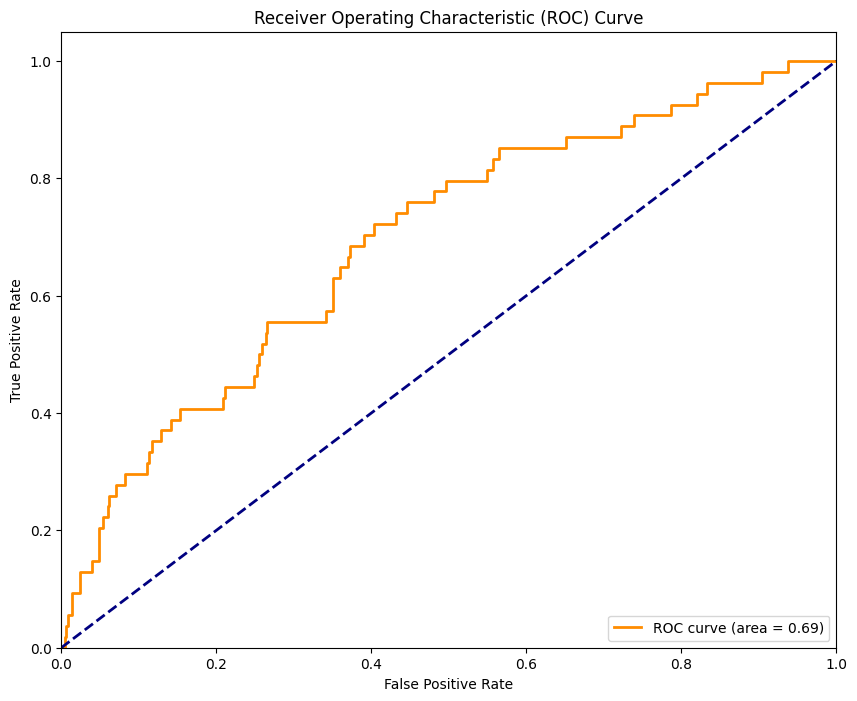

In [55]:
# Визуализация ROC-кривой
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

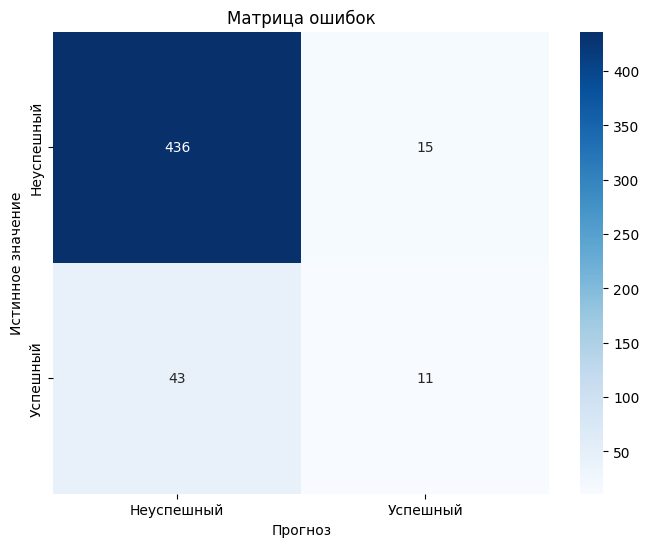

In [56]:
# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Неуспешный', 'Успешный'],
            yticklabels=['Неуспешный', 'Успешный'])
plt.xlabel('Прогноз')
plt.ylabel('Истинное значение')
plt.title('Матрица ошибок')
plt.show()

Сохранение модели для дальнейшего использования
Обученную модель и токенизатор необходимо сохранить для последующего использования:

In [57]:
# Сохранение модели и токенизатора
model_path = "./film_success22_model"
model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)
print(f"Модель сохранена в {model_path}")

Модель сохранена в ./film_success_model


Функция для прогнозирования успешности новых фильмов
Создадим удобную функцию для прогнозирования успешности новых фильмов на основе их текстовых характеристик:

In [58]:
# Функция для предсказания успешности фильма по новым данным
def predict_film_success(name, genre, tagline, logline, annotation):
    # Объединение текстовых полей
    combined_text = f"{name} {genre} {tagline} {logline} {annotation}"

    # Токенизация
    inputs = tokenizer(
        combined_text,
        padding='max_length',
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )

    # Перемещаем входные данные на то же устройство, что и модель
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Предсказание
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][prediction].item()

    result = "Успешный" if prediction == 1 else "Неуспешный"
    return result, confidence

In [59]:
# Пример использования функции
test_name = "Тестовый фильм"
test_genre = "комедия триллер"
test_tagline = "Захватывающий триллер года"
test_logline = "Главный герой оказывается в ловушке времени и должен найти выход"
test_annotation = "Молодой ученый случайно создает временную петлю, в которой оказывается заперт. Теперь ему предстоит найти способ разорвать эту петлю и вернуться в реальность, пока не стало слишком поздно."

In [60]:
result, confidence = predict_film_success(test_name, test_genre, test_tagline, test_logline, test_annotation)
print(f"Прогноз: фильм будет {result}")
print(f"Уверенность: {confidence:.4%}")

Прогноз: фильм будет Неуспешный
Уверенность: 81.0861%
